In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests
import numpy as np 
#from bias_utils import *


import constants as c 
import helpers as h 
from logger import setup_logger 
log = setup_logger("311-biases")
log.setLevel("INFO")
log.info("Modules loaded.")

h.latex(True)

2026-05-31 12:27:08 - 311-biases - INFO - Modules loaded.


2026-05-31 12:27:08 - analysis-helpers - INFO - Enabling LaTeX for matplotlib.


In [2]:
analysis_df = pd.read_csv(c.CURRENT_DF)
analysis_df = h.add_covariate_cols(analysis_df)
analysis_df = h.add_estimate_cols(analysis_df)
analysis_df = h.add_demo_cols(analysis_df)


2026-05-31 12:27:08 - analysis-helpers - INFO - Found 192 tracts with at least one FloodNet sensor.


2026-05-31 12:27:08 - analysis-helpers - INFO - Found 2171 311 requests.


2026-05-31 12:27:08 - analysis-helpers - INFO - Found 878 tracts with at least one 311 report.


2026-05-31 12:27:08 - analysis-helpers - INFO - Found 1001 tracts with no DEP flooding.


2026-05-31 12:27:08 - analysis-helpers - INFO - Found 176 tracts with confirmed flooding.


...

2026-05-31 12:27:08 - analysis-helpers - WARNING - Column 'frac_children' has 82 NA values.


2026-05-31 12:27:08 - analysis-helpers - WARNING - Column 'frac_elderly' has 82 NA values.


2026-05-31 12:27:08 - analysis-helpers - WARNING - Column 'frac_internet' has 93 NA values.


2026-05-31 12:27:08 - analysis-helpers - WARNING - Column 'frac_smartphone' has 93 NA values.


2026-05-31 12:27:08 - analysis-helpers - WARNING - Column 'frac_limited_english' has 93 NA values.


In [3]:
analysis_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2325 entries, 0 to 2324
Data columns (total 68 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   BoroName                                      2325 non-null   str    
 1   BoroCT2020                                    2325 non-null   int64  
 2   NTAName                                       2325 non-null   str    
 3   CDTANAME                                      2325 non-null   str    
 4   PUMA                                          2325 non-null   int64  
 5   empirical_estimate                            2319 non-null   float64
 6   p_y                                           2325 non-null   float64
 7   p_y_CI_lower                                  2325 non-null   float64
 8   p_y_CI_upper                                  2325 non-null   float64
 9   n_images_by_area                              2325 non-null   int64  
 10 

# basic exploratory analysis

In [4]:
pd.set_option('display.max_columns', 500)

analysis_df.head()


,BoroName,BoroCT2020,NTAName,CDTANAME,PUMA,empirical_estimate,p_y,p_y_CI_lower,p_y_CI_upper,n_images_by_area,empirical_estimate_p_alop,at_least_one_positive_image_by_area,at_least_one_positive_image_by_area_CI_lower,at_least_one_positive_image_by_area_CI_upper,total_population,nhl_white_alone,nhl_black_alone,hispanic_alone,nhl_asian_alone,n_children,n_elderly,total_households,num_households_with_internet,num_households_with_smartphone,median_household_income,num_high_school_graduates,num_bachelors_degree,num_graduate_degree,num_limited_english_speaking_households,ft_elevation_min,ft_elevation_max,ft_elevation_mean,area,n_floodnet_sensors,n_catch_basins,catch_basin_density,cb_days_clogged,has_clogged_cb_complaint,cb_avg_resolution_time,dep_moderate_1_area,dep_moderate_1_frac,dep_moderate_2_area,dep_moderate_2_frac,GEOID,sewer_backup_311c,street_flooding_311c,catch_basin_clogged/flooding_311c,manhole_overflow_311c,highway_flooding_311c,any_sensors,n_311_reports,any_311_report,no_dep_flooding,confirmed_flooding,above_thres,confirmed_or_above_thres,frac_white,frac_black,frac_hispanic,frac_asian,frac_hs,frac_bachelors,frac_grad,frac_children,frac_elderly,frac_internet,frac_smartphone,frac_limited_english
0,Manhattan,1000100,The Battery-Governors Island-Ellis Island-Libe...,MN01 Financial District-Tribeca (CD 1 Equivalent),4121,NaN,0.059687,1.652865e-312,1.000000,0,NaN,0.000000,0.000000,0.000000,0,0,0,0,0,0,0,0,0,0,NaN,0,0,0,0,0.0,19.0,8.153329,1.842847e+06,0.0,0.0,0.000000,0.0,0,0.0,0.000000,0.000000,0.000000,0.000000,36061000100,0,0,0,0,0,False,0,False,True,False,True,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Manhattan,1000201,Chinatown-Two Bridges,MN03 Lower East Side-Chinatown (CD 3 Equivalent),4103,0.000000,0.002002,2.326344e-05,0.012153,345,0.000000,0.323765,0.007994,0.985280,2568,171,359,1487,486,1114,379,823,674,661,38657.0,282,160,49,221,0.0,37.0,10.417681,9.723125e+05,0.0,14.0,0.000014,0.0,0,0.0,0.000000,0.000000,0.000000,0.000000,36061000201,0,0,0,0,0,False,0,False,True,False,False,False,0.066589,0.139798,0.579050,0.189252,0.109813,0.062305,0.019081,0.433801,0.147586,0.818955,0.803159,0.268530
2,Manhattan,1000600,Chinatown-Two Bridges,MN03 Lower East Side-Chinatown (CD 3 Equivalent),4103,0.002217,0.008113,5.828994e-04,0.026918,902,0.002217,1.000000,1.000000,1.000000,10179,1135,681,2978,5023,1018,2697,5243,4204,4371,34473.0,2155,1521,634,1596,0.0,41.0,10.160654,2.582706e+06,0.0,57.0,0.000022,0.0,0,0.0,22123.775465,0.008566,28743.307693,0.011129,36061000600,0,1,0,0,0,False,1,True,False,True,True,True,0.111504,0.066902,0.292563,0.493467,0.211710,0.149425,0.062285,0.100010,0.264957,0.801831,0.833683,0.304406
3,Manhattan,1001401,Lower East Side,MN03 Lower East Side-Chinatown (CD 3 Equivalent),4103,0.000000,0.000983,1.465489e-05,0.005964,259,0.000000,0.167955,0.003788,0.787592,3395,2371,65,370,258,328,1311,1761,1471,1385,94076.0,398,930,790,100,24.0,43.0,34.847163,1.006117e+06,0.0,13.0,0.000013,0.0,0,0.0,0.000000,0.000000,0.000000,0.000000,36061001401,1,0,0,0,0,False,1,True,True,False,False,False,0.698380,0.019146,0.108984,0.075994,0.117231,0.273932,0.232695,0.096613,0.386156,0.835321,0.786485,0.056786
4,Manhattan,1001402,Lower East Side,MN03 Lower East Side-Chinatown (CD 3 Equivalent),4103,0.000000,0.000122,1.964080e-06,0.000786,705,0.000000,0.070526,0.001384,0.425483,3449,1008,249,813,1166,249,910,1807,1520,1584,50347.0,311,1014,360,647,13.0,42.0,27.553037,1.226207e+06,0.0,44.0,0.000036,0.0,0,0.0,3811.632650,0.003108,7439.195282,0.006067,36061001402,0,0,0,0,0,False,0,False,False,False,False,False,0.292259,0.072195,0.235720,0.338069,0.090171,0.293998,0.104378,0.072195,0.263845,0.841173,0.876591,0.358052


In [5]:

# drop rows with 0 population 
analysis_df = analysis_df[analysis_df['total_population'] > 0]

In [6]:
# log total population and median household income 
analysis_df['total_population'] = np.log(analysis_df['total_population'])
analysis_df['median_household_income'] = np.log(analysis_df['median_household_income'])

In [7]:
vars = ['frac_white', 'frac_black', 'frac_hispanic', 'frac_asian', 'median_household_income', 'frac_hs', 'frac_bachelors', 'frac_grad', 'frac_internet', 'frac_smartphone', 'frac_limited_english', 'frac_children', 'frac_elderly', 'total_population']

analysis_df['median_household_income'] = analysis_df['median_household_income'].replace(-666666666, np.nan)

to_standardize =[ 'frac_hs', 'frac_bachelors', 'frac_grad', 'frac_internet', 'frac_smartphone', 'frac_limited_english', 'frac_children', 'frac_elderly', 'frac_white', 'frac_black', 'frac_hispanic', 'frac_asian', 'median_household_income', 'total_population']
for var in to_standardize:
    analysis_df[var] = (analysis_df[var] - analysis_df[var].mean()) / analysis_df[var].std()

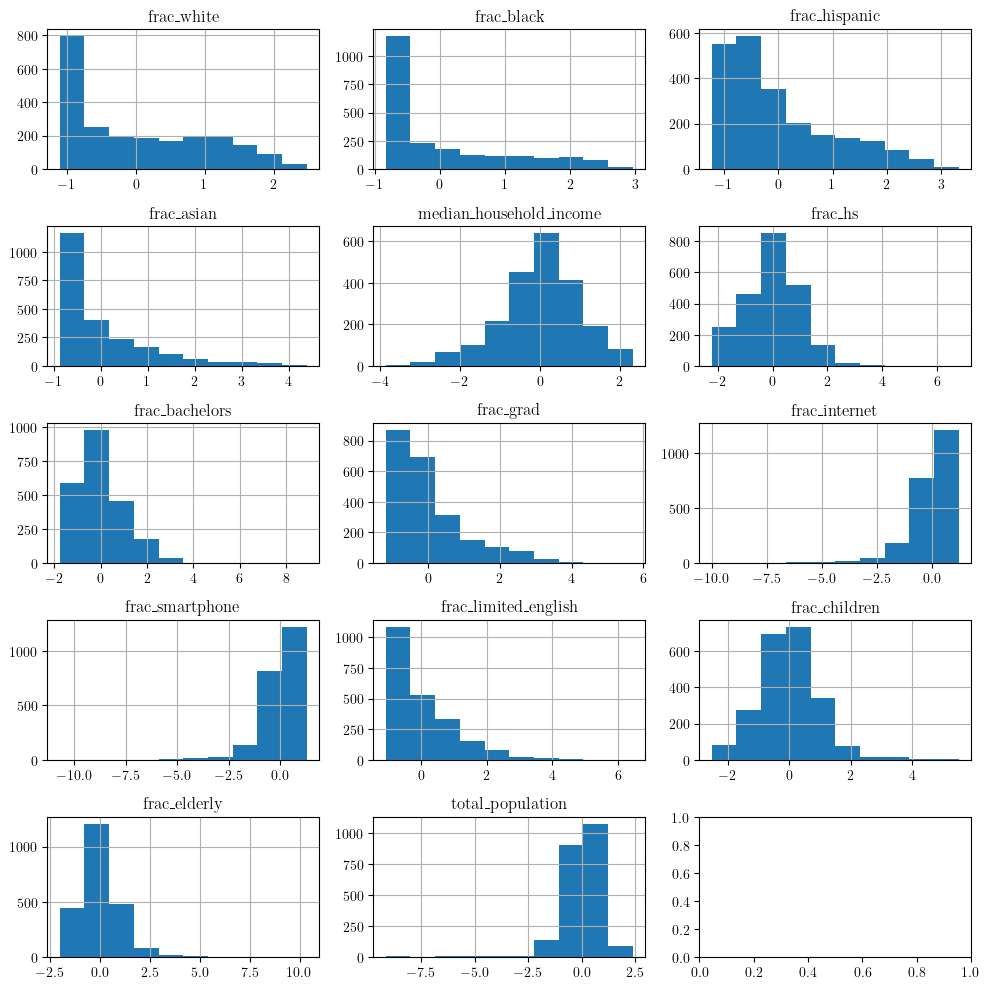

In [8]:
# make small histograms side by side for each var in vars 
fig, axs = plt.subplots(5, 3, figsize=(10, 10))
for i, var in enumerate(vars):
    ax = axs[i//3, i%3]
    analysis_df[var].hist(ax=ax)
    ax.set_title(var)
plt.tight_layout()



In [9]:
analysis_df['any_311_report'] = analysis_df['any_311_report'].astype(int)  


def get_bias_metrics(model, var):
    """
    Extract bias metrics from a fitted statsmodels model for a given variable.
    
    Parameters:
    -----------
    model : statsmodels.discrete.discrete_model.BinaryResultsWrapper
        Fitted logistic regression model
    var : str
        Name of the variable to extract metrics for
        
    Returns:
    --------
    pd.DataFrame
        Single row dataframe with metrics for the variable
    """
    params = model.params
    conf_int = model.conf_int()
    
    return pd.DataFrame({
        'variable': [var],
        'mean': [params[var]],
        'ci_lower': [conf_int.loc[var, 0]],
        'ci_upper': [conf_int.loc[var, 1]],
        'p_value': [model.pvalues[var]],
        'std_err': [model.bse[var]]
    })

def analyze_biases(data, outcome='any_311_report', predictor='p_y', 
                  variables=['frac_white', 'frac_black', 'frac_hispanic', 
                           'frac_asian', 'median_household_income', 'frac_hs', 'frac_bachelors', 'frac_grad', 'frac_internet', 'frac_smartphone', 'frac_limited_english']):
    """
    Analyze biases across multiple variables using logistic regression.
    
    Parameters:
    -----------
    data : pd.DataFrame
        Input dataset
    outcome : str
        Name of binary outcome variable
    predictor : str
        Name of main predictor variable
    variables : list
        List of variables to analyze for bias
        
    Returns:
    --------
    pd.DataFrame
        Compiled bias metrics for all variables
    """
    bias_df = pd.DataFrame()
    
    for var in variables:
        # Standardize continuous variables
        data_std = data.copy()
        data_std[var] = (data_std[var] - data_std[var].mean()) / data_std[var].std()
        
        # Fit model with interaction
        formula = f'{outcome} ~ {predictor} + {var}'  # Simplified model without interaction
        try:
            model = sm.Logit.from_formula(formula, data=data_std).fit(
            )
            bias_metrics = get_bias_metrics(model, var)
            bias_df = pd.concat([bias_df, bias_metrics], ignore_index=True)
        except Exception as e:
            print(f"Error fitting model for {var}: {str(e)}")
            
    return bias_df

# Example usage:
# bias_results = analyze_biases(d_income)

bias_results = analyze_biases(analysis_df, outcome='any_311_report', variables=vars)
confirmed_bias_results = analyze_biases(analysis_df, outcome='any_311_report', variables=vars, predictor='confirmed_or_above_thres')



Optimization terminated successfully.
         Current function value: 0.652496
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.654072
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.646192
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.653277
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.648642
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.653797
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.653554
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.654043
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.652211
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.652570
  

In [10]:
# replace variable names 
mapping = {
    'frac_white': 'Fraction White',
    'frac_black': 'Fraction Black',
    'frac_hispanic': 'Fraction Hispanic',
    'frac_asian': 'Fraction Asian',
    'median_household_income': '$log($Median Household Income$)$',
    'frac_hs': 'Fraction High School Graduates',
    'frac_bachelors': 'Fraction Bachelor\'s Degree',
    'frac_grad': 'Fraction Graduate Degree',
    'frac_internet': 'Fraction Households with Internet',
    'frac_smartphone': 'Fraction Households with Smartphone',
    'frac_limited_english': 'Fraction Households with Limited English',
    'frac_children': r'Fraction Children ($<$ 18 yrs)',
    'frac_elderly': r'Fraction Elderly ( $\leq$ 65 years)',
    'total_population': '$log($Total Population$)$',
}

bias_results['variable'] = bias_results['variable'].map(mapping)
confirmed_bias_results['variable'] = confirmed_bias_results['variable'].map(mapping)

bias_results = bias_results.set_index('variable')
confirmed_bias_results = confirmed_bias_results.set_index('variable')


# --- Multiple-comparison correction (added in revision) ---
# The 14 single-demographic logistic regressions above report UNCORRECTED p-values.
# Add (do not replace) Benjamini-Hochberg FDR and Bonferroni corrected p-values so
# the raw p_value, coefficients, and the bias figure are left unchanged.
for _df in (bias_results, confirmed_bias_results):
    _df['p_value_bh_fdr'] = multipletests(_df['p_value'].values, method='fdr_bh')[1]
    _df['p_value_bonferroni'] = multipletests(_df['p_value'].values, method='bonferroni')[1]


In [11]:
def plot_CIs_covariates(CIs_df, crop_plots=True, ax=None, figsize=(6, 6),
                        covariate_names=None, show=True, ylabel_size=16,
                        xlabel_size=12,
                        color_CIs_by_significance=True, fill_between=False, horizontal_lines=True):
    
    if ax is None: fig, ax = plt.subplots(figsize=figsize)
    
    CIs_df = CIs_df.replace({'-':np.nan}).dropna()
    if covariate_names is None: covariate_names = CIs_df.index.values
    
    estimates = CIs_df.loc[covariate_names, 'mean'].values
    UB = CIs_df.loc[covariate_names, 'ci_upper'].values
    LB = CIs_df.loc[covariate_names, 'ci_lower'].values
    CIs = np.vstack([estimates-LB, UB-estimates])

    
    # Get p-values from dataframe
    p_values = CIs_df['p_value'].values

    #Collect colors:
    if color_CIs_by_significance:
        colors = ['red' if ub < 0 else ('blue' if lb > 0 else 'grey')
                 for ub, lb in list(zip(UB, LB))]

        # color in if p-value is significant, else only color the edge 
        mfcs = ['none']*len(estimates)
        for i, p in enumerate(p_values):
            if p < 0.05:
                mfcs[i] = colors[i]
                
    else:
        colors = ['black']*len(estimates)

    #Plot:
    for estimate, name, CI, color, mfc, p_value in zip(estimates[::-1],
                                         covariate_names[::-1],
                                         CIs[::, ::-1].T,
                                         colors[::-1],
                                            mfcs[::-1],
                                         p_values[::-1]):
        _ = ax.errorbar(x=estimate,
                        y=name,
                        xerr=CI.reshape(2,1),
                        ecolor=color,
                        capsize=5,
                        linestyle='None',
                        linewidth=1.5,
                        marker="d",
                        markersize=5,
                        mfc=mfc,
                        mec=color)
        print(f"{name}: {estimate:.2f} ({estimate-CI[0]:.2f}, {estimate+CI[1]:.2f}). Significance: {p_value:.3f}")

    ax.tick_params(axis='y', labelsize=ylabel_size)
    ax.tick_params(axis='x', labelsize=xlabel_size)
    #Grids:
    xlim = ax.get_xlim()
    _ = ax.axvline(0, linestyle='--', color='black', alpha=0.75, zorder=-1, linewidth=1.)

    if fill_between:
        _ = ax.fill_between(np.linspace(xlim[0], xlim[1], 1000, endpoint=True), -0.5, 1.5, alpha=.4, color='lightgrey', linewidth=0)
        _ = ax.fill_between(np.linspace(xlim[0], xlim[1], 1000, endpoint=True), 6.5, 8.5, alpha=.4, color='lightgrey', linewidth=0)
        _ = ax.fill_between(np.linspace(xlim[0], xlim[1], 1000, endpoint=True), 10.5, 14.5, alpha=.4, color='lightgrey', linewidth=0)
    if horizontal_lines:
        for y, c in enumerate(colors[::-1]):
            _ = ax.hlines(y=y, xmin=-3, xmax=3, linestyle='--', linewidth=0.5, alpha=0.5, color='grey')
    _ = ax.set_xlim(xlim)
    _ = ax.set_ylim(-0.5, len(estimates)-0.5)

    # x axis label
    _ = ax.set_xlabel(r'$\beta_d$', fontsize=16)
            
    if show: plt.show()
        
    return ax

In [12]:
bias_results

,mean,ci_lower,ci_upper,p_value,std_err,p_value_bh_fdr,p_value_bonferroni
variable,,,,,,,
Fraction White,0.117532,0.031885,0.203179,7.153234e-03,0.043698,3.338176e-02,1.001453e-01
Fraction Black,0.017020,-0.068857,0.102897,6.976883e-01,0.043816,7.513566e-01,1.000000e+00
Fraction Hispanic,-0.271230,-0.362641,-0.179818,6.046168e-09,0.046639,8.464636e-08,8.464636e-08
Fraction Asian,0.083803,-0.001095,0.168701,5.302804e-02,0.043316,1.484785e-01,7.423926e-01
$log($Median Household Income$)$,0.193763,0.103964,0.283562,2.346400e-05,0.045817,1.642480e-04,3.284960e-04
Fraction High School Graduates,0.051726,-0.034426,0.137878,2.392846e-01,0.043956,3.349984e-01,1.000000e+00
Fraction Bachelor's Degree,0.068831,-0.016814,0.154475,1.152161e-01,0.043697,2.304323e-01,1.000000e+00
Fraction Graduate Degree,-0.023307,-0.109606,0.062993,5.965832e-01,0.044031,6.960137e-01,1.000000e+00
Fraction Households with Internet,0.061543,-0.026516,0.149603,1.707504e-01,0.044929,2.656117e-01,1.000000e+00


**Multiple-comparison correction.** The table above reports the raw (uncorrected) p-values together with Benjamini-Hochberg FDR (`p_value_bh_fdr`) and Bonferroni (`p_value_bonferroni`) corrected p-values across the 14 single-demographic logistic regressions. After correction, the associations for **White (raw p=0.013)**, **Asian (raw p=0.045)**, and **Children (raw p=0.02)** no longer survive at $\alpha=0.05$, whereas **Hispanic (raw p=3.5e-9)** and **$\log$(Household income) (raw p=2.1e-5)** remain significant under both the BH-FDR and the more conservative Bonferroni correction.

$log($Total Population$)$: 0.07 (-0.02, 0.16). Significance: 0.105
Fraction Elderly ( $\leq$ 65 years): -0.01 (-0.10, 0.07). Significance: 0.753
Fraction Children ($<$ 18 yrs): 0.10 (0.01, 0.19). Significance: 0.023
Fraction Households with Limited English: -0.07 (-0.15, 0.02). Significance: 0.137
Fraction Households with Smartphone: -0.02 (-0.11, 0.06). Significance: 0.580
Fraction Households with Internet: 0.06 (-0.03, 0.15). Significance: 0.171
Fraction Graduate Degree: -0.02 (-0.11, 0.06). Significance: 0.597
Fraction Bachelor's Degree: 0.07 (-0.02, 0.15). Significance: 0.115
Fraction High School Graduates: 0.05 (-0.03, 0.14). Significance: 0.239
$log($Median Household Income$)$: 0.19 (0.10, 0.28). Significance: 0.000
Fraction Asian: 0.08 (-0.00, 0.17). Significance: 0.053
Fraction Hispanic: -0.27 (-0.36, -0.18). Significance: 0.000
Fraction Black: 0.02 (-0.07, 0.10). Significance: 0.698
Fraction White: 0.12 (0.03, 0.20). Significance: 0.007


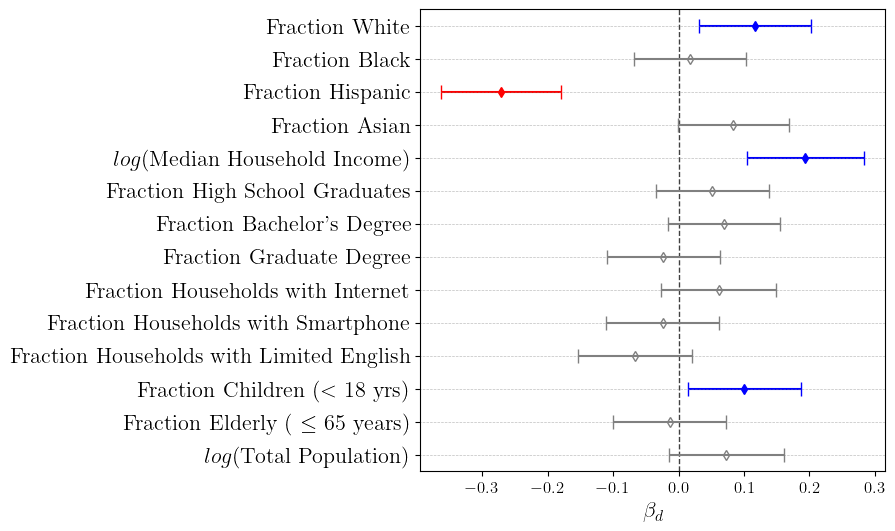

In [13]:
fig = plot_CIs_covariates(bias_results, show=False)
plt.savefig(f'{c.PAPER_PATH}/figures/bias.pdf', bbox_inches='tight', dpi=300)
# save figure 



In [14]:
confirmed_bias_results

,mean,ci_lower,ci_upper,p_value,std_err,p_value_bh_fdr,p_value_bonferroni
variable,,,,,,,
Fraction White,0.099969,0.013702,0.186237,2.313128e-02,0.044015,8.095948e-02,3.238379e-01
Fraction Black,0.034365,-0.051626,0.120357,4.334669e-01,0.043874,5.057114e-01,1.000000e+00
Fraction Hispanic,-0.270575,-0.362303,-0.178846,7.409914e-09,0.046801,1.037388e-07,1.037388e-07
Fraction Asian,0.084804,-0.000477,0.170086,5.129485e-02,0.043512,1.436256e-01,7.181279e-01
$log($Median Household Income$)$,0.182117,0.092952,0.271281,6.249222e-05,0.045493,4.374455e-04,8.748911e-04
Fraction High School Graduates,0.062599,-0.023805,0.149002,1.556137e-01,0.044084,2.189587e-01,1.000000e+00
Fraction Bachelor's Degree,0.062120,-0.023786,0.148026,1.563990e-01,0.043830,2.189587e-01,1.000000e+00
Fraction Graduate Degree,-0.035727,-0.122566,0.051111,4.200302e-01,0.044306,5.057114e-01,1.000000e+00
Fraction Households with Internet,0.069012,-0.018780,0.156804,1.233884e-01,0.044792,2.159297e-01,1.000000e+00


$log($Total Population$)$: 0.08 (-0.00, 0.17). Significance: 0.062
Fraction Elderly ( $\leq$ 65 years): -0.02 (-0.10, 0.07). Significance: 0.698
Fraction Children ($<$ 18 yrs): 0.11 (0.02, 0.20). Significance: 0.013
Fraction Households with Limited English: -0.07 (-0.16, 0.02). Significance: 0.123
Fraction Households with Smartphone: -0.02 (-0.11, 0.07). Significance: 0.629
Fraction Households with Internet: 0.07 (-0.02, 0.16). Significance: 0.123
Fraction Graduate Degree: -0.04 (-0.12, 0.05). Significance: 0.420
Fraction Bachelor's Degree: 0.06 (-0.02, 0.15). Significance: 0.156
Fraction High School Graduates: 0.06 (-0.02, 0.15). Significance: 0.156
$log($Median Household Income$)$: 0.18 (0.09, 0.27). Significance: 0.000
Fraction Asian: 0.08 (-0.00, 0.17). Significance: 0.051
Fraction Hispanic: -0.27 (-0.36, -0.18). Significance: 0.000
Fraction Black: 0.03 (-0.05, 0.12). Significance: 0.433
Fraction White: 0.10 (0.01, 0.19). Significance: 0.023


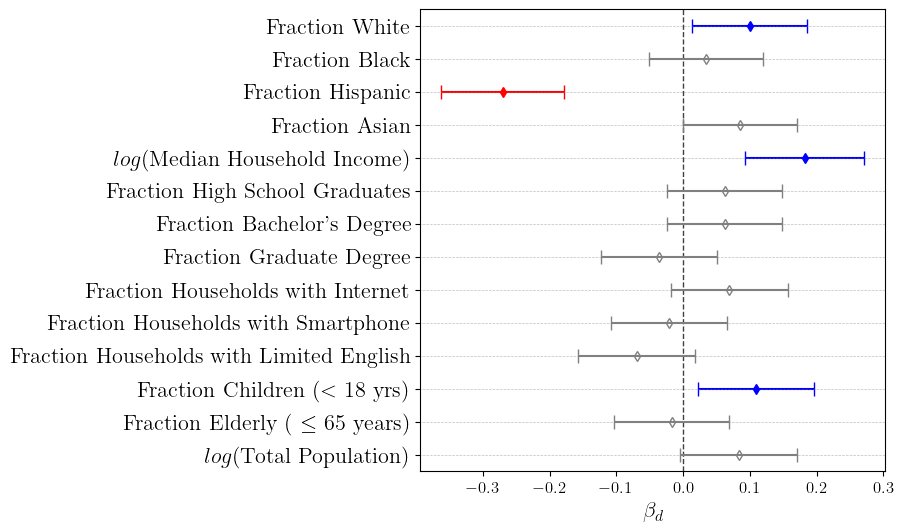

In [15]:
fig_confirmed = plot_CIs_covariates(confirmed_bias_results, show=False)
plt.savefig(f'{c.PAPER_PATH}/figures/confirmed_bias.pdf', bbox_inches='tight', dpi=300)
# save figure 
